# Proyecto 2 - Pronóstico Climático Local

## 01_Carga_y_EDA.ipynb

Este notebook documenta la carga de datos, la inspección básica y el análisis exploratorio inicial de la serie de tiempo climática.

### Objetivos
- Cargar los archivos `DailyDelhiClimateTrain.csv` y `DailyDelhiClimateTest.csv`
- Examinar la estructura y calidad de los datos
- Visualizar tendencias temporales y distribuciones
- Generar una primera versión del informe HTML

## About Dataset

### Content

The Dataset is fully dedicated for the developers who want to train the model on Weather Forecasting for Indian climate. This dataset provides data from **1st January 2013** to **24th April 2017** in the city of Delhi, India. The 4 parameters here are **meantemp, humidity, wind_speed, meanpressure**.

### Acknowledgements

This dataset has been collected from Weather Undergroud API. Dataset ownership and credit goes to them.

### Submission Deadline

Assignment 4 must be submitted by October 19, 2019 (10:00 PM). Any kernel published after this deadline will be evaluated for only 50% of the total marks.

### Inspiration

This dataset was developed as a part Assignment 4 of Data Analytics Course, 2019 at PES University, Bangalore.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', font_scale=1.1)

train_path = '../data/DailyDelhiClimateTrain.csv'
test_path = '../data/DailyDelhiClimateTest.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)

Train shape: (1462, 5)
Test shape: (114, 5)


## Estructura del Dataset

A continuación revisamos los primeros registros y el tipo de cada columna.

In [2]:
train_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [4]:
train_df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


## Revisión de Valores Faltantes y Duplicados

In [5]:
print('Valores faltantes en train:')
print(train_df.isna().sum())
print('\nValores faltantes en test:')
print(test_df.isna().sum())
print('\nDuplicados en train:', train_df.duplicated().sum())
print('Duplicados en test:', test_df.duplicated().sum())

Valores faltantes en train:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Valores faltantes en test:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Duplicados en train: 0
Duplicados en test: 0


## Análisis Temporal y Distribuciones

Visualizamos la evolución de la temperatura y los patrones de las variables principales.

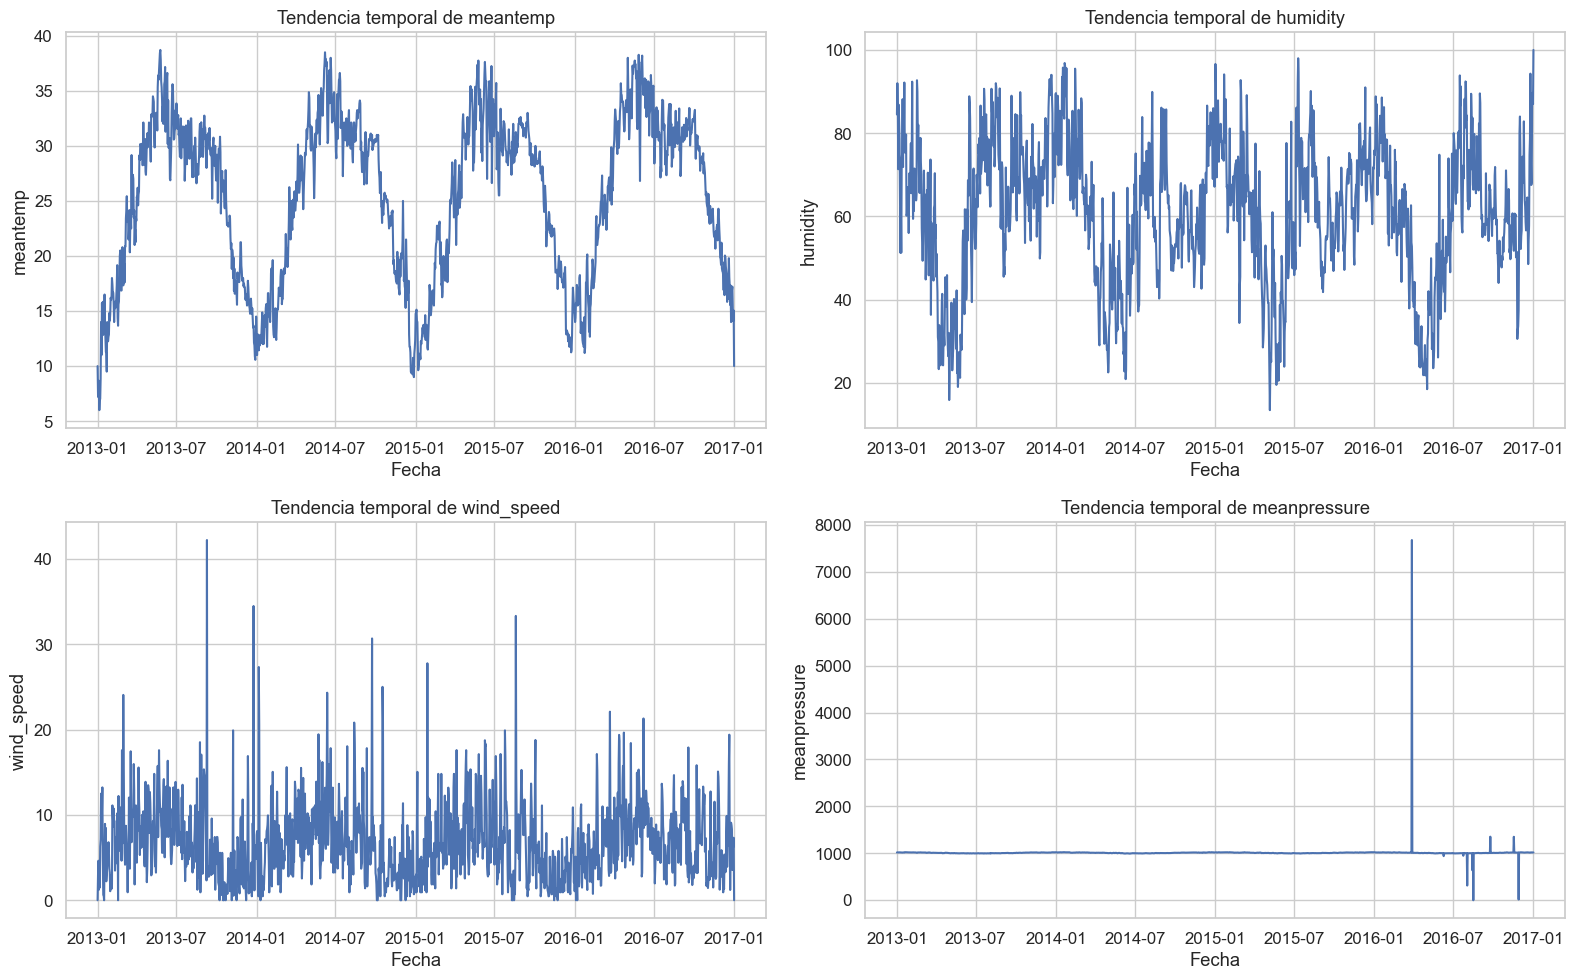

In [6]:
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.ravel(), ['meantemp', 'humidity', 'wind_speed', 'meanpressure']):
    sns.lineplot(data=train_df, x='date', y=col, ax=ax)
    ax.set_title(f'Tendencia temporal de {col}')
    ax.set_xlabel('Fecha')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

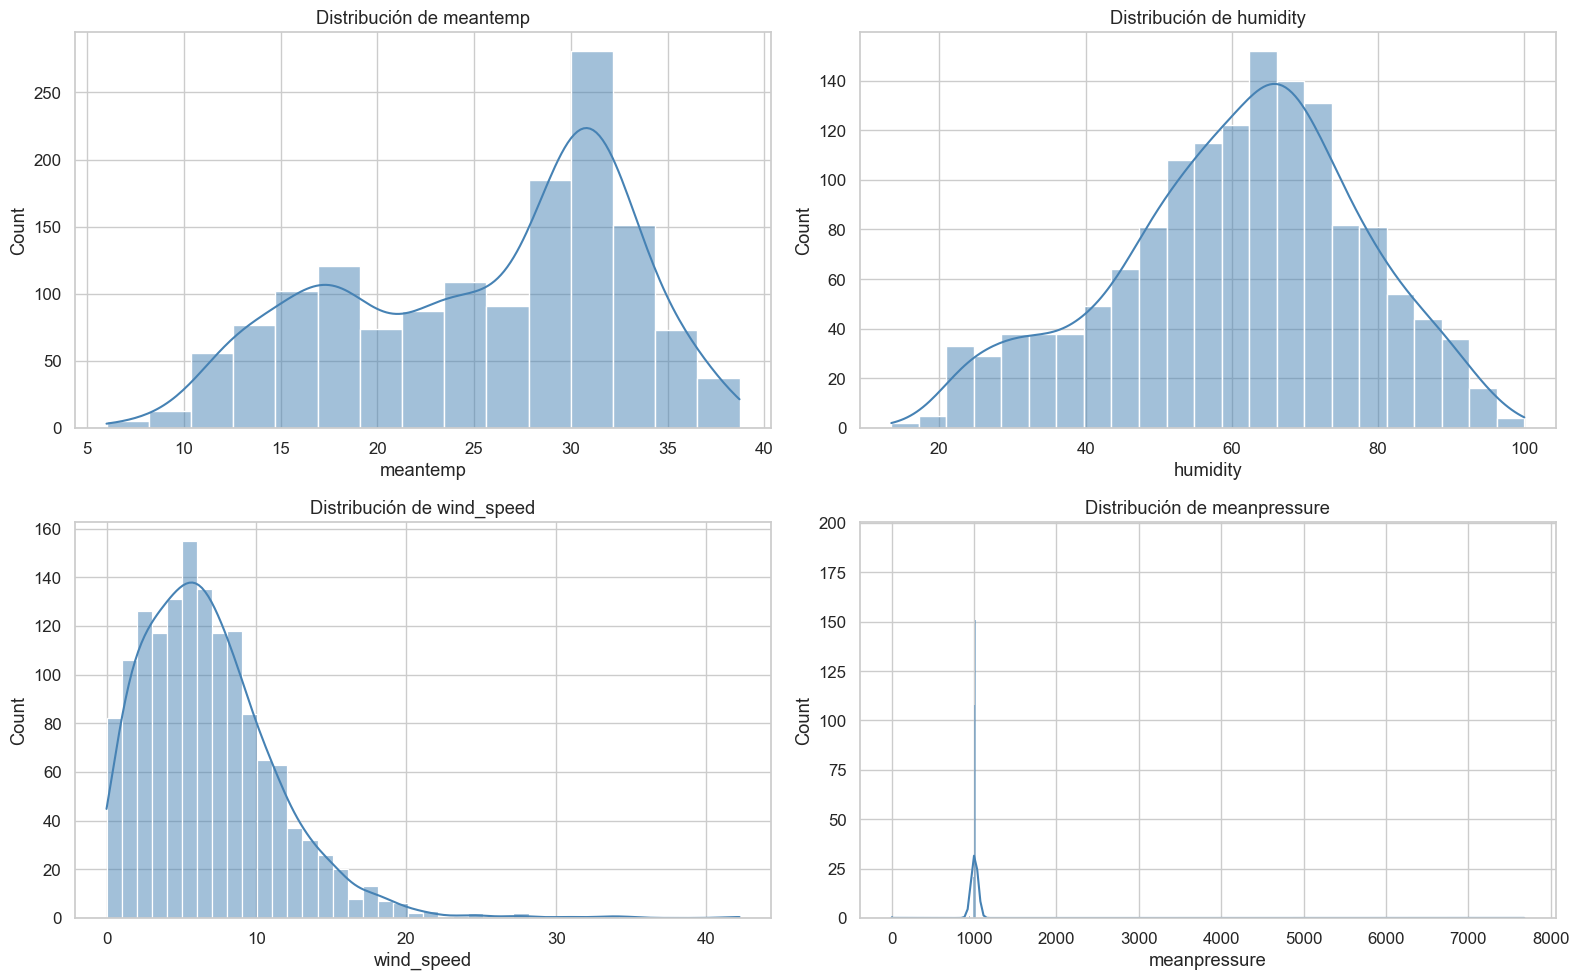

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.ravel(), ['meantemp', 'humidity', 'wind_speed', 'meanpressure']):
    sns.histplot(train_df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

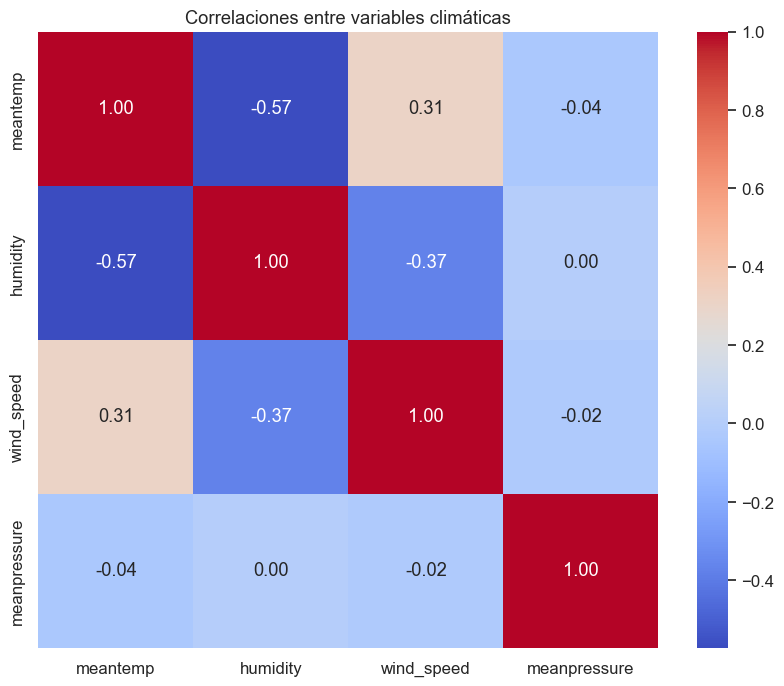

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[['meantemp', 'humidity', 'wind_speed', 'meanpressure']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlaciones entre variables climáticas')
plt.show()

## Comparación entre Train y Test

In [9]:
print('Train.mean()')
print(train_df[['meantemp', 'humidity', 'wind_speed', 'meanpressure']].mean())
print('\nTest.mean()')
print(test_df[['meantemp', 'humidity', 'wind_speed', 'meanpressure']].mean())

Train.mean()
meantemp          25.495521
humidity          60.771702
wind_speed         6.802209
meanpressure    1011.104548
dtype: float64

Test.mean()
meantemp          21.713079
humidity          56.258362
wind_speed         8.143924
meanpressure    1004.035090
dtype: float64


## Exportar a HTML

Al final, podemos generar un informe HTML para compartir los resultados del EDA.

In [12]:
# Para generar el informe HTML desde la terminal:
!jupyter nbconvert --to html ../notebooks/01_Carga_y_EDA.ipynb --output ../reports/01_Carga_y_EDA.html
print('Genera el informe HTML con nbconvert si es necesario.')

Genera el informe HTML con nbconvert si es necesario.


[NbConvertApp] Converting notebook ../notebooks/01_Carga_y_EDA.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 814260 bytes to ..\notebooks\..\reports\01_Carga_y_EDA.html
